# Lesson 10: Image Retrieval

- In the classroom, the libraries are already installed for you.
- If you would like to run this code on your own machine, you can install the following:

```
    !pip install transformers
    !pip install torch
```

- Here is some code that suppresses warning messages.

In [1]:
from transformers.utils import logging
logging.set_verbosity_error()

- Load the model and the processor

In [2]:
from transformers import BlipForImageTextRetrieval

In [3]:
model = BlipForImageTextRetrieval.from_pretrained(
    "./models/Salesforce/blip-itm-base-coco")

More info about [Salesforce/blip-itm-base-coco](https://huggingface.co/Salesforce/blip-itm-base-coco).

In [4]:
from transformers import AutoProcessor

In [5]:
processor = AutoProcessor.from_pretrained(
    "./models/Salesforce/blip-itm-base-coco")

In [6]:
img_url = 'https://storage.googleapis.com/sfr-vision-language-research/BLIP/demo.jpg'

In [7]:
from PIL import Image
import requests

In [8]:
raw_image = Image.open(
    requests.get(img_url, stream=True).raw).convert('RGB')

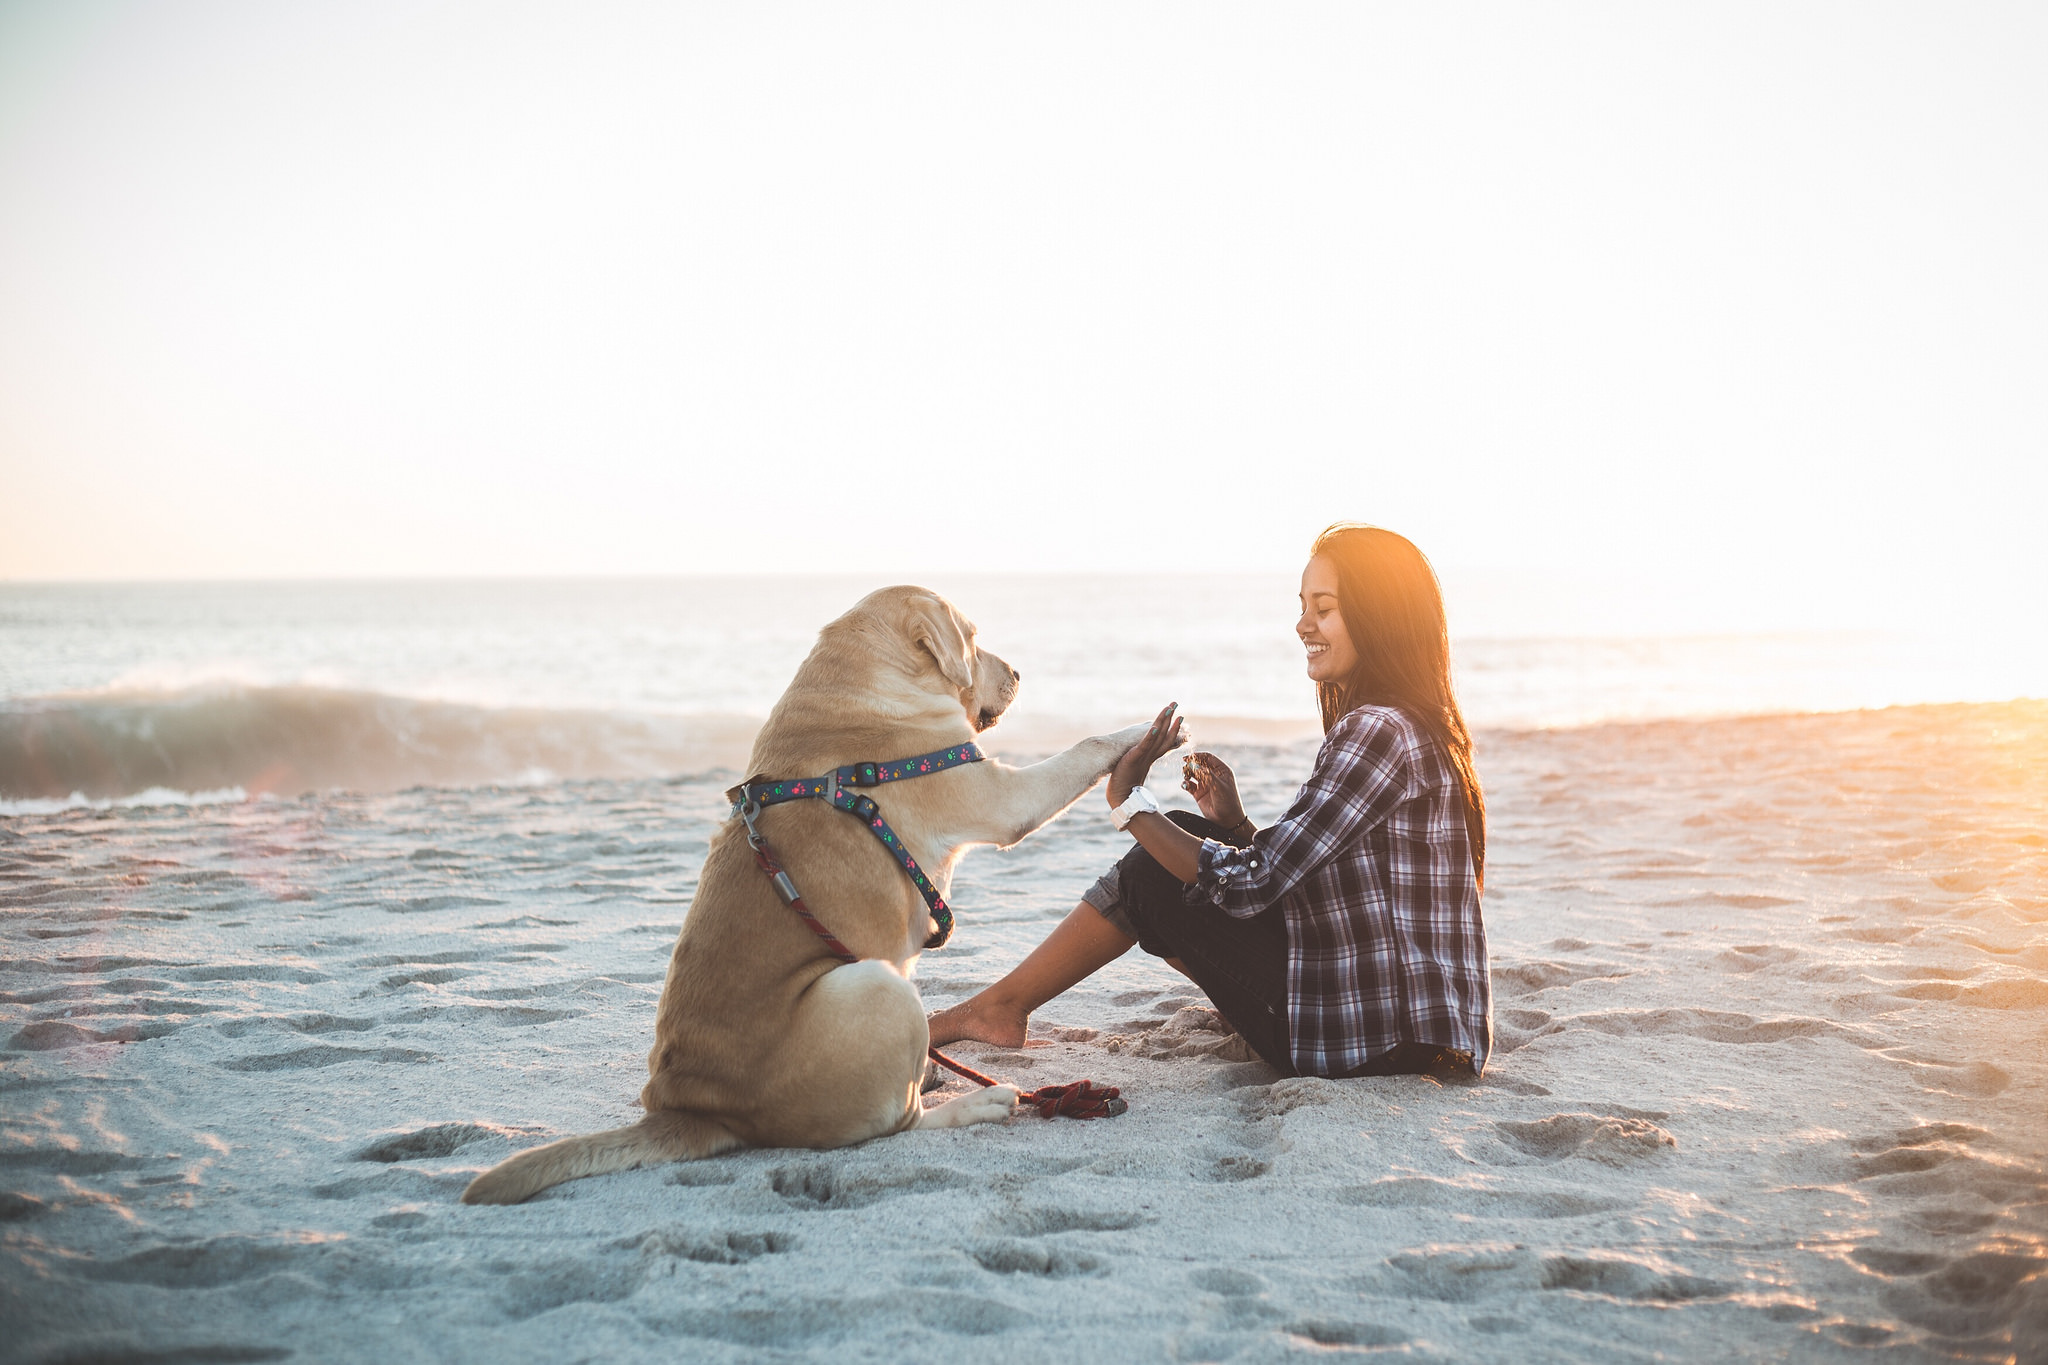

In [9]:
raw_image

In [10]:
raw_image.size

(2048, 1365)

### Test, if the image matches the text

In [11]:
text = "an image of a woman and a dog on the beach"

In [12]:
inputs = processor(images=raw_image,
                   text=text,
                   return_tensors="pt")

In [13]:
inputs

{'pixel_values': tensor([[[[ 0.8647,  0.9230,  0.9376,  ...,  1.7552,  1.7552,  1.7552],
          [ 0.9084,  0.9376,  0.9522,  ...,  1.7552,  1.7552,  1.7552],
          [ 0.9376,  0.9376,  0.9668,  ...,  1.7552,  1.7552,  1.7552],
          ...,
          [-0.7850, -0.7850, -0.7266,  ..., -0.3178, -0.2740, -0.3616],
          [-0.7558, -0.7558, -0.7412,  ..., -0.3178, -0.3616, -0.4346],
          [-0.7558, -0.7704, -0.7850,  ..., -0.3616, -0.4346, -0.4784]],

         [[ 1.2194,  1.2495,  1.2795,  ...,  1.8948,  1.8948,  1.8948],
          [ 1.2344,  1.2645,  1.2945,  ...,  1.8948,  1.8948,  1.8948],
          [ 1.2495,  1.2795,  1.3095,  ...,  1.8948,  1.8948,  1.8948],
          ...,
          [-0.5965, -0.5965, -0.5515,  ..., -0.4014, -0.3264, -0.4164],
          [-0.5665, -0.5665, -0.5515,  ..., -0.3864, -0.4164, -0.4914],
          [-0.5665, -0.5815, -0.5965,  ..., -0.4164, -0.4764, -0.5365]],

         [[ 1.2927,  1.3211,  1.3496,  ...,  1.9753,  1.9753,  1.9753],
          [ 1

In [14]:
itm_scores = model(**inputs)[0]

In [15]:
inputs.keys()

dict_keys(['pixel_values', 'input_ids', 'attention_mask'])

In [16]:
# [batch_size, channels, height, width]
inputs['pixel_values'].shape

torch.Size([1, 3, 384, 384])

In [17]:
inputs['input_ids'].shape

torch.Size([1, 13])

In [18]:
inputs['attention_mask'].shape

torch.Size([1, 13])

In [19]:
itm_scores

tensor([[-2.2228,  2.2260]], grad_fn=<AddmmBackward0>)

In [20]:
import torch

- Use a softmax layer to get the probabilities

In [21]:
itm_score = torch.nn.functional.softmax(
    itm_scores, dim=1)

In [22]:
itm_score

tensor([[0.0116, 0.9884]], grad_fn=<SoftmaxBackward0>)

In [23]:
print(f"""\
The image and text are matched \
with a probability of {itm_score[0][1]:.4f}""")

The image and text are matched with a probability of 0.9884


In [24]:
print(f"""\
The image and text are not matched \
with a probability of {itm_score[0][0]:.4f}""")

The image and text are not matched with a probability of 0.0116


### Try it yourself! 
- Try this model with your own images and texts!

In [25]:
img_url = "https://luxurylondon.co.uk/wp-content/uploads/2022/08/horse-riding-london-1-2930x2198-c-center.jpg"

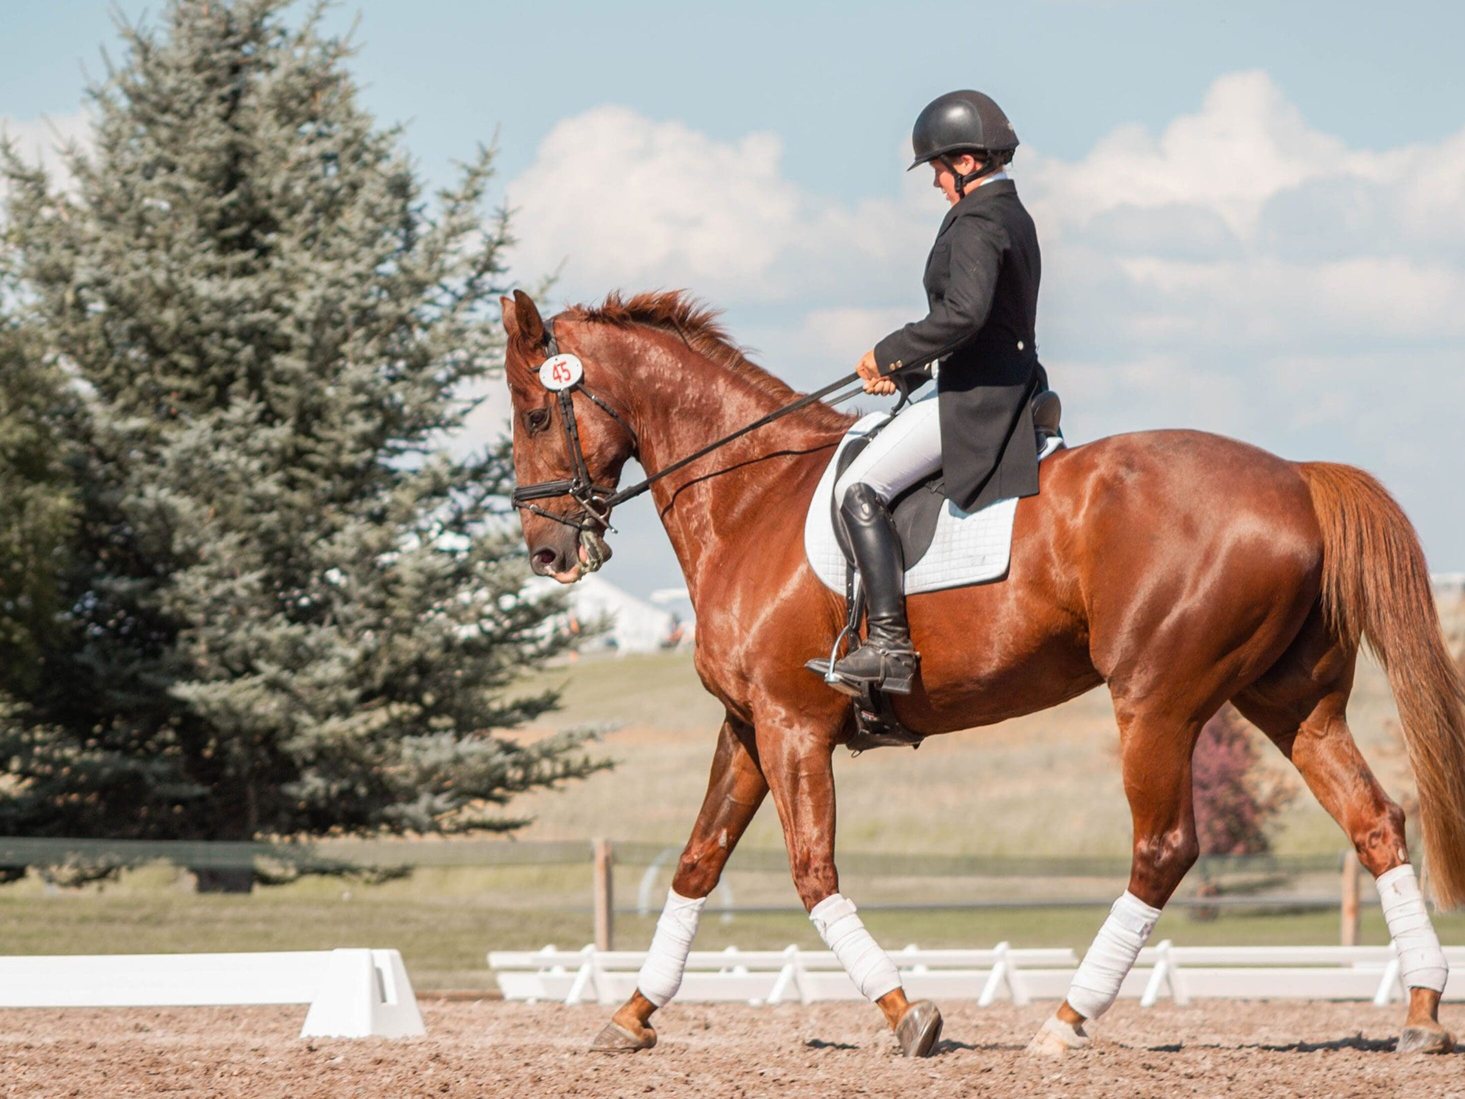

In [26]:
raw_image = Image.open(
    requests.get(img_url, stream=True).raw).convert('RGB')
width, height = raw_image.size
raw_image = raw_image.resize((width // 2, height // 2))
raw_image

In [27]:
raw_image.size

(1465, 1099)

In [28]:
text = "An image of a person riding a horse"
inputs = processor(images=raw_image,
                   text=text,
                   return_tensors="pt")
inputs

{'pixel_values': tensor([[[[ 0.7479,  0.7479,  0.7479,  ...,  0.8647,  0.8647,  0.8647],
          [ 0.7479,  0.7479,  0.7479,  ...,  0.8647,  0.8647,  0.8647],
          [ 0.7625,  0.7625,  0.7479,  ...,  0.8647,  0.8647,  0.8647],
          ...,
          [ 1.2588,  1.1566,  1.2150,  ...,  0.9084,  0.8647,  1.2296],
          [ 0.8063,  0.8938,  1.3902,  ...,  1.4632,  1.4340,  1.3610],
          [ 0.4997,  0.5727,  1.2588,  ...,  1.0982,  1.0836,  1.3172]],

         [[ 1.2645,  1.2645,  1.2645,  ...,  1.2495,  1.2495,  1.2495],
          [ 1.2645,  1.2645,  1.2645,  ...,  1.2495,  1.2495,  1.2495],
          [ 1.2795,  1.2795,  1.2645,  ...,  1.2495,  1.2495,  1.2495],
          ...,
          [ 0.8292,  0.6491,  0.7092,  ...,  0.4540,  0.4991,  0.8292],
          [ 0.2740,  0.3940,  1.0243,  ...,  1.1894,  1.1144,  0.9493],
          [-0.1313,  0.0338,  0.8593,  ...,  0.6792,  0.7542,  0.9493]],

         [[ 1.5344,  1.5344,  1.5344,  ...,  1.5060,  1.5060,  1.5060],
          [ 1

In [29]:
# [CLS] + tokens + [SEP]
# commas are also tokens
print(inputs.input_ids.shape) 

torch.Size([1, 10])


In [30]:
outputs = model(**inputs)
len(outputs)

3

In [31]:
print(type(outputs))

<class 'transformers.models.blip.modeling_blip.BlipImageTextMatchingModelOutput'>


In [32]:
outputs[0]

tensor([[-0.1538,  0.1536]], grad_fn=<AddmmBackward0>)

In [33]:
# Image Patch Embeddings
outputs[1], outputs[1].shape

(tensor([[[ 0.7733,  0.8383, -0.0540,  ..., -0.8066,  1.0493,  0.4214],
          [-0.8024, -0.2648,  0.7818,  ..., -0.4747,  0.8321, -0.2725],
          [ 0.2866, -0.0046, -0.0496,  ..., -0.1281, -0.1191, -0.6881],
          ...,
          [ 0.6230,  0.0846,  0.1830,  ..., -0.6367,  0.3497, -0.3696],
          [ 0.4427,  0.8924,  0.3533,  ..., -0.9517,  0.7648,  0.2127],
          [-0.0161,  0.7951,  0.2084,  ..., -0.7030,  0.3491, -0.0149]]],
        grad_fn=<NativeLayerNormBackward0>),
 torch.Size([1, 577, 768]))

In [34]:
# Text Embeddings
outputs[2], outputs[2].shape

(tensor([[[-0.0064,  0.0815,  0.0426,  ...,  0.0564,  0.0009, -0.0015],
          [-0.0549,  0.0202,  0.0078,  ...,  0.0601, -0.0262, -0.0176],
          [-0.0849,  0.0182,  0.0219,  ...,  0.0816,  0.0012, -0.0094],
          ...,
          [ 0.0422,  0.0418, -0.0118,  ...,  0.0132, -0.0074, -0.0266],
          [ 0.0724,  0.0269, -0.0052,  ..., -0.0501, -0.0440, -0.0478],
          [-0.0064,  0.0815,  0.0427,  ...,  0.0564,  0.0009, -0.0015]]],
        grad_fn=<NativeLayerNormBackward0>),
 torch.Size([1, 10, 768]))

In [35]:
itm_scores = outputs[0]
itm_score = torch.nn.functional.softmax(
    itm_scores, dim=1)
itm_score

tensor([[0.4238, 0.5762]], grad_fn=<SoftmaxBackward0>)

In [36]:
print(f"""\
The image and text are matched \
with a probability of {itm_score[0][1]:.4f}""")

The image and text are matched with a probability of 0.5762


Small text changes can cause large probability shifts in BLIP's Image-Text Matching (ITM) model

In [ ]:
# text = "An image of a person and a horse"
# This sentence gets a probability of 0.0016